In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_excel("dataset_rumah.xlsx")
df.head(10)

,luas,kamar,jarak_kota,harga,kategori
0,102,3,5,565,sedang
1,55,2,10,310,murah
2,130,4,3,720,mahal
3,80,3,7,480,sedang
4,45,1,15,250,murah
5,140,4,2,780,mahal
6,90,3,6,510,sedang
7,60,2,12,340,murah
8,120,4,4,690,mahal
9,75,2,8,420,sedang


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   luas        15 non-null     int64
 1   kamar       15 non-null     int64
 2   jarak_kota  15 non-null     int64
 3   harga       15 non-null     int64
 4   kategori    15 non-null     str  
dtypes: int64(4), str(1)
memory usage: 732.0 bytes


In [6]:
df.describe(include="all")

,luas,kamar,jarak_kota,harga,kategori
count,15.000000,15.000000,15.000000,15.000000,15
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,sedang
freq,NaN,NaN,NaN,NaN,6
mean,89.466667,2.800000,7.400000,505.000000,NaN
std,31.948321,0.941124,4.119639,177.834192,NaN
min,45.000000,1.000000,2.000000,250.000000,NaN
25%,62.500000,2.000000,4.500000,350.000000,NaN
50%,85.000000,3.000000,6.000000,500.000000,NaN
75%,115.000000,3.500000,10.500000,655.000000,NaN


In [7]:
df.isnull().sum()

luas          0
kamar         0
jarak_kota    0
harga         0
kategori      0
dtype: int64

In [8]:
X = df[["luas", "kamar", "jarak_kota"]]
y = df["harga"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)

*Evaluasi Model*

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 59.701693128490426
R2 Score: 0.9967266814611245


In [13]:
print("\n===Prediksi harga rumah===")

try:
    luas = float(input("Masukkan luas rumah (m2): "))
    kamar = int(input("Masukkan jumlah kamar: "))
    jarak_kota = float(input("Masukkan jarak ke kota (km): "))

    new_data = np.array([[luas, kamar, jarak_kota]])

    predicted_price = model.predict(new_data)
    print(f"\nPrediksi harga rumah: {predicted_price[0]:.2f} IDR")
except ValueError:
    print("Input tidak valid. Pastikan memasukkan angka yang benar.")


===Prediksi harga rumah===

Prediksi harga rumah: 1980.39 IDR


c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
from sklearn.linear_model import LogisticRegression

X = df[["luas", "kamar", "jarak_kota"]]
y = df["kategori"]

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X_test)

c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.0


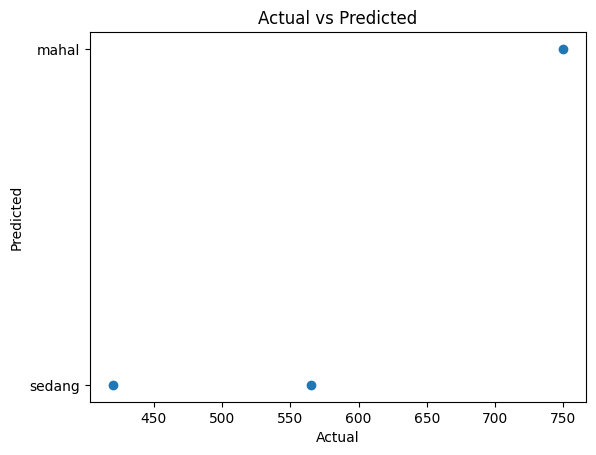

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# klafikasi
X = df[["luas", "kamar", "jarak_kota"]]
y = df["kategori"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       mahal       1.00      1.00      1.00         1
      sedang       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [19]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1 0]
 [0 2]]


**Pertemuan 6**

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [21]:
df = pd.read_excel("dataset_rumah.xlsx")
print(df.head(10))

   luas  kamar  jarak_kota  harga kategori
0   102      3           5    565   sedang
1    55      2          10    310    murah
2   130      4           3    720    mahal
3    80      3           7    480   sedang
4    45      1          15    250    murah
5   140      4           2    780    mahal
6    90      3           6    510   sedang
7    60      2          12    340    murah
8   120      4           4    690    mahal
9    75      2           8    420   sedang


In [ ]:
x = df[["luas", "kamar", "jarak_kota"]]
y = df["kategori"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [26]:
y_pred = model.predict(X_test)

print("===Prediksi kategori rumah===")
print(accuracy_score(y_test, y_pred))
print("\n===Laporan Klasifikasi===")
print(classification_report(y_test, y_pred))

===Prediksi kategori rumah===
0.6666666666666666

===Laporan Klasifikasi===
              precision    recall  f1-score   support

       mahal       1.00      1.00      1.00         1
       murah       0.00      0.00      0.00         0
      sedang       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.67      0.50      0.56         3
weighted avg       1.00      0.67      0.78         3



c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [27]:
print("===Prediksi kategori rumah===")

try:
    luas = float(input("Masukkan luas rumah (m2): "))
    kamar = int(input("Masukkan jumlah kamar: "))
    jarak_kota = float(input("Masukkan jarak ke kota (km): "))

    new_data = np.array([[luas, kamar, jarak_kota]])

    result = model.predict(new_data)
    print(f"\nPrediksi kategori rumah: {result[0]}")

except ValueError:
    print("Input tidak valid. Pastikan memasukkan angka yang benar.")

===Prediksi kategori rumah===

Prediksi kategori rumah: sedang


c:\Users\IIK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
